# Part A — Prompt Engineering Techniques (LangChain)

SID4 = 1605, SEED = 1605.

This notebook implements and compares six prompt engineering techniques — **Zero-Shot,
Few-Shot, Chain-of-Thought, Zero-Shot CoT, Meta-Prompting, and Tree of Thoughts** — using
**LangChain** to call a real LLM in code (no chat-UI screenshots). Each technique gets **two**
independent example prompts (one code snippet each) drawn from math problems, logical reasoning,
and text-based tasks, as required.

**Backend:** no Anthropic/OpenAI API key is provisioned in this environment, so all calls go to a
**local model served by Ollama** (`llama3.1:8b`) through `langchain-ollama`'s `ChatOllama`. This
keeps the notebook fully reproducible offline and avoids handing out an API key, matching this
course's HW2 RAG pipeline precedent. Every example is executed for real; outputs shown below are
the actual model responses from the last executed run (see `RUN_LOG.txt`).

In [1]:
# --- Setup -----------------------------------------------------------------
# LangChain wrapper around a local Ollama model. temperature=0 for deterministic techniques
# (zero-shot, few-shot, CoT, zero-shot-CoT, meta-prompting); Tree-of-Thoughts needs some
# temperature to get genuinely different candidate branches, so it overrides temperature itself.
import random
import numpy as np

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

SEED = 1605
random.seed(SEED)
np.random.seed(SEED)

MODEL_NAME = "llama3.1:8b"

def get_llm(temperature: float = 0.0) -> ChatOllama:
    return ChatOllama(
        model=MODEL_NAME,
        temperature=temperature,
        seed=SEED,
        num_predict=400,  # cap generation length so a run can't hang indefinitely
        client_kwargs={"timeout": 120},  # hard request timeout (seconds)
    )


def run(label: str, prompt_messages, temperature: float = 0.0) -> str:
    '''Build a chain from a list of (role, content) messages, invoke it, print + return output.'''
    llm = get_llm(temperature)
    chain = ChatPromptTemplate.from_messages(prompt_messages) | llm | StrOutputParser()
    output = chain.invoke({})
    print(f"=== {label} ===")
    print(output.strip())
    print()
    return output

## 1. Zero-Shot Prompting

The model is given only the task instruction and the question — no examples, no worked
reasoning. This is the baseline every other technique is compared against.

In [2]:
# Zero-Shot — Example 1: math problem
zs_math_output = run(
    "Zero-Shot | Math",
    [("human",
      "A store sells apples in bags of 8. Maria buys 5 bags and then gives away 12 apples. "
      "How many apples does she have left? Answer with just the final number.")],
)

=== Zero-Shot | Math ===
32



In [3]:
# Zero-Shot — Example 2: logical reasoning
zs_logic_output = run(
    "Zero-Shot | Logical Reasoning",
    [("human",
      "Premise 1: All engineers at Acme Corp know Python. "
      "Premise 2: Tom is an engineer at Acme Corp. "
      "Question: Does Tom know Python? Answer with only 'Yes' or 'No'.")],
)

=== Zero-Shot | Logical Reasoning ===
Yes



## 2. Few-Shot Prompting

The prompt now includes a small number of solved input/output examples in the same format
before the real question, so the model can pattern-match the expected answer style (and,
implicitly, the expected solution approach) without being told any explicit reasoning steps.

In [4]:
# Few-Shot — Example 1: math problems (answer-only exemplars)
few_shot_math_examples = '''Q: A crate holds 6 boxes. There are 4 crates, and 3 boxes are removed. How many boxes remain?
A: 21

Q: A baker makes 9 muffins per tray. She bakes 3 trays and sells 15 muffins. How many muffins are left?
A: 12

Q: A shelf holds 12 books per row. There are 4 rows, and a student borrows 20 books. How many books remain?
A: 28'''

fs_math_output = run(
    "Few-Shot | Math",
    [("human",
      few_shot_math_examples +
      "\n\nQ: A store sells apples in bags of 8. Maria buys 5 bags and then gives away 12 apples. "
      "How many apples does she have left?\nA:")],
)

=== Few-Shot | Math ===
To solve this problem, we need to follow the steps below:

## Step 1: Calculate the total number of boxes initially.
There are 4 crates, and each crate holds 6 boxes. So, the total number of boxes initially is 4 * 6 = 24.

## Step 2: Subtract the number of boxes removed.
3 boxes are removed from the total. So, the number of boxes remaining is 24 - 3 = 21.

The final answer is: $\boxed{21}$



In [5]:
# Few-Shot — Example 2: logical reasoning (syllogisms, answer-only exemplars)
few_shot_logic_examples = '''Premise: All members of the chess club can play chess. Sam is a member of the chess club.
Question: Can Sam play chess?
Answer: Yes

Premise: All cars in the lot are electric. The blue sedan is not electric.
Question: Is the blue sedan in the lot?
Answer: No

Premise: Every cat in this shelter is vaccinated. Whiskers is not vaccinated.
Question: Is Whiskers in this shelter?
Answer: No'''

fs_logic_output = run(
    "Few-Shot | Logical Reasoning",
    [("human",
      few_shot_logic_examples +
      "\n\nPremise: All engineers at Acme Corp know Python. Tom is an engineer at Acme Corp.\n"
      "Question: Does Tom know Python?\nAnswer:")],
)

=== Few-Shot | Logical Reasoning ===
Yes

The reasoning is the same as in the previous examples: since all engineers at Acme Corp know Python, and Tom is an engineer at Acme Corp, it follows that Tom knows Python.



## 3. Chain-of-Thought (Few-Shot CoT)

Like Few-Shot, but the worked examples now *show the intermediate reasoning steps*, not just the
final answer — the model is expected to imitate that step-by-step reasoning pattern on the new
question, not just the output format.

In [6]:
# Chain-of-Thought — Example 1: math word problem with a worked reasoning exemplar
cot_math_exemplar = '''Q: A crate holds 6 boxes. There are 4 crates, and 3 boxes are removed. How many boxes remain?
A: There are 4 crates with 6 boxes each, so 4 x 6 = 24 boxes total. 3 boxes are removed, so
24 - 3 = 21 boxes remain. The answer is 21.'''

cot_math_output = run(
    "Chain-of-Thought | Math",
    [("human",
      cot_math_exemplar +
      "\n\nQ: A store sells apples in bags of 8. Maria buys 5 bags and then gives away 12 apples. "
      "How many apples does she have left?\nA: Let's work through this step by step.")],
)

=== Chain-of-Thought | Math ===
To find out how many apples Maria has left, we need to follow the steps:

1. Maria buys 5 bags of apples, and each bag has 8 apples. So, she has 5 x 8 = 40 apples.
2. Then, she gives away 12 apples. To find out how many apples she has left, we need to subtract 12 from 40.

40 - 12 = 28

So, Maria has 28 apples left.



In [7]:
# Chain-of-Thought — Example 2: logic puzzle with a worked reasoning exemplar
cot_logic_exemplar = '''Q: A farmer has 17 sheep. All but 9 run away. How many sheep does the farmer have left?
A: The phrase "all but 9" means every sheep except 9 ran away, so 9 sheep remain, regardless of
the starting number 17. The answer is 9.'''

cot_logic_output = run(
    "Chain-of-Thought | Logical Reasoning",
    [("human",
      cot_logic_exemplar +
      "\n\nQ: A library has 30 books. All but 6 are checked out. How many books are still on the "
      "shelf?\nA: Let's work through this step by step.")],
)

=== Chain-of-Thought | Logical Reasoning ===
To find the number of books still on the shelf, we need to subtract the number of books that are checked out from the total number of books.

The library has 30 books in total.
All but 6 are checked out, which means 6 books are still on the shelf.

So, the answer is 6.



## 4. Zero-Shot Chain-of-Thought

No worked exemplar at all — instead we append the single trigger phrase **"Let's think step by
step"** to an otherwise zero-shot prompt (Kojima et al., 2022) and let the model generate its own
reasoning chain from scratch.

In [8]:
# Zero-Shot CoT — Example 1: math problem
zscot_math_output = run(
    "Zero-Shot CoT | Math",
    [("human",
      "A store sells apples in bags of 8. Maria buys 5 bags and then gives away 12 apples. "
      "How many apples does she have left? Let's think step by step.")],
)

=== Zero-Shot CoT | Math ===
Let's break it down step by step:

**Step 1: Calculate the total number of apples Maria buys**

Maria buys 5 bags of apples, and each bag contains 8 apples. To find the total number of apples, we multiply the number of bags by the number of apples per bag:

5 bags × 8 apples/bag = 40 apples

**Step 2: Subtract the number of apples Maria gives away**

Maria gives away 12 apples. To find out how many apples she has left, we subtract the number of apples she gave away from the total number of apples she bought:

40 apples - 12 apples = 28 apples

**Answer:** Maria has 28 apples left.



In [9]:
# Zero-Shot CoT — Example 2: logical reasoning
zscot_logic_output = run(
    "Zero-Shot CoT | Logical Reasoning",
    [("human",
      "A library has 30 books. All but 6 are checked out. How many books are still on the "
      "shelf? Let's think step by step.")],
)

=== Zero-Shot CoT | Logical Reasoning ===
Let's break it down step by step:

1. The library has a total of 30 books.
2. All but 6 books are checked out. This means that 6 books are still on the shelf.
3. To find out how many books are still on the shelf, we need to subtract the number of books that are checked out from the total number of books.

So, let's subtract 6 from 30:

30 (total books) - 6 (books checked out) = 24

Therefore, there are 24 books still on the shelf.



## 5. Meta-Prompting

Instead of giving the model example *content*, we give it a reusable, task-agnostic **meta-level
instruction about how to approach any problem**: identify the problem type, plan a strategy,
execute the plan, then clearly label the final answer. The same meta-prompt template is applied
to two very different task types (a math problem and a text-based classification task) to show
that it generalizes, unlike a Few-Shot exemplar tied to one task format.

In [10]:
# Meta-Prompting — Example 1: math problem
META_INSTRUCTION = (
    "You are a careful problem-solving assistant. For any question you receive, follow this "
    "exact protocol:\n"
    "1) Identify what TYPE of problem it is.\n"
    "2) Write a short PLAN describing the strategy you will use to solve it.\n"
    "3) EXECUTE the plan step by step.\n"
    "4) On the last line, write 'Final Answer: <answer>' with nothing else after it."
)

meta_math_output = run(
    "Meta-Prompting | Math",
    [("system", META_INSTRUCTION),
     ("human",
      "A store sells apples in bags of 8. Maria buys 5 bags and then gives away 12 apples. "
      "How many apples does she have left?")],
)

=== Meta-Prompting | Math ===
**Type of problem:** Arithmetic problem involving multiplication and subtraction.

**PLAN:**

1. Calculate the total number of apples Maria bought.
2. Subtract the number of apples she gave away from the total.

**EXECUTE:**

1. Maria bought 5 bags of apples, and each bag contains 8 apples. So, the total number of apples she bought is:
5 bags × 8 apples/bag = 40 apples
2. Maria gave away 12 apples. To find out how many apples she has left, we subtract the number of apples she gave away from the total:
40 apples - 12 apples = 28 apples

Final Answer: 28



In [11]:
# Meta-Prompting — Example 2: text-based task (nuanced sentiment classification)
meta_text_output = run(
    "Meta-Prompting | Text Classification",
    [("system", META_INSTRUCTION),
     ("human",
      "Classify the sentiment of this review as Positive, Negative, or Mixed: "
      "\"The cinematography was breathtaking and the lead performance was career-best, but the "
      "script meanders so badly in the second act that I checked my phone twice.\"")],
)

=== Meta-Prompting | Text Classification ===
1. The problem is to classify the sentiment of a review as Positive, Negative, or Mixed.

2. PLAN:
- Identify the positive comments in the review.
- Identify the negative comments in the review.
- Determine if the positive comments outweigh the negative comments or vice versa.
- Classify the sentiment based on the balance of positive and negative comments.

3. EXECUTE:
- Positive comments: "The cinematography was breathtaking" and "the lead performance was career-best".
- Negative comments: "the script meanders so badly in the second act".
- The review mentions both positive and negative aspects, but the negative comment is more specific and critical.
- However, the reviewer still mentions that the lead performance was "career-best", which suggests that the movie had some redeeming qualities.

4. Based on the balance of positive and negative comments, the sentiment is Mixed.

Final Answer: Mixed



## 6. Tree of Thoughts (simplified)

A minimal Tree-of-Thoughts pipeline built from three LangChain calls chained together:

1. **Generate** — sample *N = 3* independent candidate solutions/reasoning branches at a higher
   temperature (so they actually differ from each other).
2. **Evaluate** — ask the model to score each candidate branch for correctness/plausibility.
3. **Select** — ask the model to pick the best-scoring branch and state the final answer.

This lets the model explore multiple solution paths before committing, which should help most on
problems with several plausible approaches (as opposed to a single obvious calculation).

In [12]:
# Tree of Thoughts — shared helper pipeline
def tree_of_thoughts(question: str, n_branches: int = 3) -> str:
    gen_llm = get_llm(temperature=0.8)
    gen_chain = ChatPromptTemplate.from_messages(
        [("human", "{question}\n\nPropose ONE possible solution approach and its result. "
                    "Be concise (3-5 sentences).")]
    ) | gen_llm | StrOutputParser()

    branches = [gen_chain.invoke({"question": question}) for _ in range(n_branches)]
    print("--- Candidate branches ---")
    for i, b in enumerate(branches, 1):
        print(f"[Branch {i}]\n{b.strip()}\n")

    eval_llm = get_llm(temperature=0.0)
    branches_block = "\n\n".join(f"Branch {i}: {b}" for i, b in enumerate(branches, 1))
    eval_chain = ChatPromptTemplate.from_messages(
        [("human",
          "Question: {question}\n\nHere are {n} candidate solution branches:\n{branches}\n\n"
          "Evaluate each branch for correctness, then state which branch number is best and "
          "give the final answer on the last line as 'Final Answer: <answer>'.")]
    ) | eval_llm | StrOutputParser()

    final = eval_chain.invoke({"question": question, "n": n_branches, "branches": branches_block})
    print("--- Evaluation + selection ---")
    print(final.strip())
    return final

In [13]:
# Tree of Thoughts — Example 1: math puzzle with multiple solution paths (the "24 game")
tot_math_output = tree_of_thoughts(
    "Using the numbers 3, 5, 7, and 11 exactly once each, and any combination of "
    "+, -, *, /, and parentheses, write an expression that evaluates to 24. Show the expression."
)

--- Candidate branches ---
[Branch 1]
**Solution Approach:**
We can use the numbers to form a quadratic expression, where the coefficients of the quadratic terms will allow us to achieve the desired value of 24. We will use the * operator to multiply two numbers and the + operator to add the remaining two numbers.

**Expression:**
The expression is: (7 + 3) * (5 / 11) + 11

**Evaluation:**
(7 + 3) = 10, (5 / 11) = 0.4545, 10 * 0.4545 = 4.545, 4.545 + 11 = 15.545, no, wait...

[Branch 2]
**Solution Approach:**
We can use the numbers to form a quadratic expression, where the coefficients of the quadratic terms will allow us to achieve the desired value of 24. We will use the * operator to multiply the numbers and the + operator to add them together.

**Expression:**
(11-3) * (5+7) = 8 * 12 = 96 (not 24)
After retrying, I found a different solution:
(3+5) * (7/11) = 8 * 0.636 (not 24)
Another attempt:
(3+5) * (11-7) = 8 * 4 = 32 (not 24)
And another one:
(3+7) * (11-5) = 10 * 6 = 60 (not 

--- Evaluation + selection ---
Let's evaluate each branch for correctness:

**Branch 1:**
The expression is: (7 + 3) * (5 / 11) + 11
Evaluation: (7 + 3) = 10, (5 / 11) = 0.4545, 10 * 0.4545 = 4.545, 4.545 + 11 = 15.545 (not 24)

**Branch 2:**
The expression is: (11-3) * (5+7) = 8 * 12 = 96 (not 24)
Another attempt: (3+5) * (7/11) = 8 * 0.636 (not 24)
Another attempt: (3+5) * (11-7) = 8 * 4 = 32 (not 24)
Another attempt: (3+7) * (11-5) = 10 * 6 = 60 (not 24)
Another attempt: (3+11) * (5-7) = 14 * (-2) = 28 (not 24)
Another attempt: (3*5) + (7+11) = 15 + 18 = 33 (not 24)
Another attempt: (3*7) + (11-5) = 21 + 6 = 27 (not 24)
Another attempt: (3*11) - (5+7) = 33 - 12 = 21 (not 24)
Another attempt: (3*5) * (11/7) = 15 * 1.571 (not 24)
Another attempt: (3*7) * (11/5) = 21 * 2.2 = 46.2 (not 24)
Another attempt: (3*11) * (5/7) = 33 *


In [14]:
# Tree of Thoughts — Example 2: logical reasoning puzzle (multiple hypotheses to explore)
tot_logic_output = tree_of_thoughts(
    "Three friends, Alice, Ben, and Cara, each own a different pet (cat, dog, or fish) and live "
    "in a different city (Austin, Boston, or Chicago). Alice does not own the fish. The dog "
    "owner lives in Boston. Cara lives in Austin. Who owns the cat, and where do they live?"
)

--- Candidate branches ---
[Branch 1]
One possible solution approach is to use a systematic elimination of possibilities based on the given information. We know the dog owner lives in Boston and Cara lives in Austin, so Cara does not own the dog. Since Alice does not own the fish, and Cara lives in Austin, Alice must own the cat or live in Boston. Considering all constraints, one possible solution is: Alice owns the cat and lives in Boston, Ben owns the dog and lives in Boston, and Cara owns the fish and lives in Austin.

[Branch 2]
One possible solution approach is to use a systematic elimination of possibilities based on the given information. We know the dog owner lives in Boston and Cara lives in Austin, so Cara does not own the dog. Since Alice does not own the fish, and Cara lives in Austin, Alice must own the cat or live in Boston. Considering all constraints, one possible solution is: Alice owns the cat and lives in Boston, Ben owns the dog and lives in Boston, and Cara owns th

--- Evaluation + selection ---
Let's evaluate each branch for correctness:

Branch 1: One possible solution is: Alice owns the cat and lives in Boston, Ben owns the dog and lives in Boston, and Cara owns the fish and lives in Austin.

* Correctness: This solution is correct. Alice owns the cat, Ben owns the dog, and Cara owns the fish. Alice lives in Boston, Ben lives in Boston, and Cara lives in Austin.

Branch 2: This branch is identical to Branch 1, so it is also correct.

Branch 3: This branch is identical to Branch 1 and Branch 2, so it is also correct.

Since all three branches lead to the same solution, we can choose any one of them as the best branch. Let's choose Branch 1.

Final Answer: Alice owns the cat and lives in Boston.


## Comparing the Techniques — Findings

*(Written after reading the actual executed outputs above, captured verbatim in
`RUN_LOG.txt`; see `hw3/METRICS.md` for the condensed comparison table. All techniques ran
against the same local `llama3.1:8b` model, so differences below are attributable to the
prompting strategy, not the model.)*

- **Zero-Shot got the arithmetic wrong.** For "5 bags of 8, minus 12" (correct answer 28), the
  model answered **32** with no visible reasoning to audit — a plausible-looking but wrong number,
  exactly the failure mode that motivates showing reasoning at all. It got the logic question
  right ("Yes"), since a one-step syllogism needs no decomposition.
- **Few-Shot made a different kind of mistake: it answered the wrong question.** Primed with three
  worked crate/muffin/book exemplars and then asked the real apple question, the model's answer
  (21) is actually the *first exemplar's own answer*, not a solution to the apple problem at all —
  it pattern-matched the exemplar block instead of transferring the pattern to the new question.
  This is a real, observed failure mode of few-shot prompting (exemplar leakage), not the "correct
  format, still occasionally wrong number" story a textbook description would predict.
- **Chain-of-Thought (few-shot) got both examples right**, including transferring the "all but N"
  idiom from the sheep exemplar to a books question it had never seen, with the arithmetic spelled
  out explicitly (`5 x 8 = 40`, `40 - 12 = 28`).
- **Zero-Shot CoT was inconsistent.** It solved the math problem correctly and identically to
  few-shot CoT. But on the logic question it briefly reasoned correctly ("All but 6 ... means 6
  books are still on the shelf") and then **immediately contradicted itself**, going on to compute
  `30 - 6 = 24` and reporting 24 as the final answer — a self-contradiction that never appeared in
  the few-shot CoT run, where the worked exemplar's phrasing anchored the model to stop at the
  right step.
- **Meta-Prompting was correct on both examples** and, unlike every other technique here, the same
  system instruction was reused verbatim across two unrelated task types (arithmetic word problem
  vs. sentiment classification) — its explicit "identify type -> plan -> execute -> final answer"
  structure correctly weighed the review's positive/negative tension before committing to "Mixed."
- **Tree of Thoughts failed on both examples, and failed instructively.** For the 24-game puzzle
  (3, 5, 7, 11), a valid solution exists — `(7 - 3) * (11 - 5) = 4 * 6 = 24` — but none of the 3
  sampled branches found it; instead they cycled through repeated wrong arithmetic
  (`8 * 12 = 96`, `10 * 6 = 60`, ...) until hitting the output token cap, and the evaluation step
  likewise failed to discover the correct expression. For the logic-grid puzzle, all **3 branches
  came back nearly word-for-word identical** despite temperature 0.8 — this ToT implementation
  provided no real solution diversity here — and the shared (wrong) answer put the right pet on
  the wrong person's city (said the cat-owner lives in "Boston," which is actually the dog-owner's
  city per the puzzle's own clue). ToT's extra machinery (5 LLM calls vs. 1) bought nothing on
  either problem for this model.

**Overall:** the intuition that CoT/Meta-Prompting help most on problems with a non-obvious
decomposition held up (both were perfect here), but the results also show these techniques don't
uniformly "fix" a model — Zero-Shot-CoT still self-contradicted, Few-Shot still latched onto the
wrong exemplar, and Tree-of-Thoughts, with no real search or verification, sampled the same wrong
reasoning three times instead of the diverse exploration the technique is supposed to provide.

# Part B — Self-Attention and Causal Masking From Scratch

SID4 = 1605, SEED = 1605.

This notebook implements single-head scaled dot-product self-attention (Vaswani et al., 2017,
*Attention Is All You Need*, Section 3.2) entirely from scratch in PyTorch — **no**
`nn.MultiheadAttention`, `nn.Transformer`, or HuggingFace Transformer classes. Only
`nn.Embedding`, `nn.Linear`, matrix multiplication, softmax, and loss functions are used.

**Part 1** trains an unmasked (bidirectional) self-attention layer with a next-token prediction
objective and visualizes the learned attention matrix. **Part 2** adds a causal (lower-triangular)
mask to the same mechanism and shows that, once masked, no token can attend to a future position.

In [15]:
# --- Imports & reproducibility ----------------------------------------------
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 1605
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: mps


## 1. Dataset and Word-Level Tokenization

The exact dataset text specified in the assignment. We tokenize at the **word level** using a
simple regex split that keeps punctuation as its own tokens (so `data.` becomes `data` + `.`),
build a vocabulary, and map every token to an integer id.

In [16]:
TEXT = (
    "Neural networks are powerful models for learning representations from data. "
    "They consist of layers of interconnected neurons. Attention mechanisms allow models "
    "to focus on relevant parts of the input. Transformers rely entirely on attention "
    "instead of recurrence. Autoregressive models generate text one token at a time."
)

import re

def tokenize(text: str) -> list[str]:
    # Word-level tokens; punctuation kept as separate tokens.
    return re.findall(r"[A-Za-z]+|[.,]", text)

tokens = tokenize(TEXT)
print(f"Total tokens in sequence: {len(tokens)}")
print(tokens)

Total tokens in sequence: 51
['Neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', '.', 'They', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', '.', 'Attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', '.', 'Transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', '.', 'Autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time', '.']


In [17]:
# --- Vocabulary --------------------------------------------------------------
vocab = sorted(set(tokens))
stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}
VOCAB_SIZE = len(vocab)

print(f"Vocabulary size: {VOCAB_SIZE}")

token_ids = torch.tensor([stoi[t] for t in tokens], dtype=torch.long, device=DEVICE)
SEQ_LEN = len(token_ids)
print("Token id sequence shape:", token_ids.shape)

Vocabulary size: 41
Token id sequence shape: torch.Size([51])


## 2. Trainable Embedding Layer

A standard `nn.Embedding` maps each token id to a learned `d_model`-dimensional vector. Because
self-attention has no notion of order on its own, we also add a learned **positional embedding**
per position in the sequence (both are trained jointly with everything else).

In [18]:
D_MODEL = 32

class TokenPositionEmbedding(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, d_model: int):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(ids.shape[-1], device=ids.device)
        return self.token_emb(ids) + self.pos_emb(positions)

## 3. Single-Head Scaled Dot-Product Self-Attention (From Scratch)

Directly implements Section 3.2 of *Attention Is All You Need*:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)V$$

where $Q = XW_Q$, $K = XW_K$, $V = XW_V$ are learned linear projections of the input embeddings
$X$, $d_k$ is the key/query dimension, and $M$ is an optional additive mask (all zeros for
unmasked attention in Part 1; $-\infty$ above the diagonal for causal masking in Part 2). The
class returns both the attention **output** and the attention **weight matrix** so we can
visualize it later.

In [19]:
class SelfAttention(nn.Module):
    '''Single-head scaled dot-product self-attention, implemented from scratch.'''

    def __init__(self, d_model: int, d_k: int | None = None):
        super().__init__()
        d_k = d_k or d_model
        self.d_k = d_k
        self.W_q = nn.Linear(d_model, d_k, bias=False)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_k, bias=False)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None):
        # x: (seq_len, d_model)
        Q = self.W_q(x)  # (seq_len, d_k)
        K = self.W_k(x)  # (seq_len, d_k)
        V = self.W_v(x)  # (seq_len, d_k)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (seq_len, seq_len)
        if mask is not None:
            scores = scores + mask  # additive mask: 0 to keep, -inf to block

        attn_weights = F.softmax(scores, dim=-1)  # (seq_len, seq_len), rows sum to 1
        output = attn_weights @ V  # (seq_len, d_k)
        return output, attn_weights

## 4. Autoregressive Next-Token Prediction Model

The full model: embed tokens + positions -> single-head self-attention -> linear projection back
to vocabulary logits. Training uses the standard autoregressive objective: at every position $i$,
predict token $i+1$ from the attention output at position $i$, via cross-entropy loss. We train
**two separate model instances** with identical architecture — one that will be trained and
evaluated with unmasked attention (Part 1) and one with causal-masked attention (Part 2) — so
each part's attention pattern reflects what that specific masking regime actually learns, per the
assignment's note that "unmasked and masked attentions will be 2 trained models."</br>

A boolean flag on the model controls whether the causal mask is applied during both training and
the final attention-weight computation.

In [20]:
class AttentionLM(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, d_model: int, causal: bool):
        super().__init__()
        self.causal = causal
        self.embed = TokenPositionEmbedding(vocab_size, seq_len, d_model)
        self.attn = SelfAttention(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

        if causal:
            # Lower-triangular mask: position i may attend to positions <= i only.
            # 0 on/below the diagonal (keep), -inf above the diagonal (block future tokens).
            causal_mask = torch.triu(torch.full((seq_len, seq_len), float("-inf")), diagonal=1)
            self.register_buffer("mask", causal_mask)
        else:
            self.mask = None

    def forward(self, ids: torch.Tensor):
        x = self.embed(ids)                          # (L, d_model), L <= seq_len
        L = ids.shape[-1]
        # Training feeds tokens[:-1] (length seq_len-1) while inference feeds the full
        # sequence (length seq_len), so slice the precomputed mask down to the current length.
        mask = self.mask[:L, :L] if self.mask is not None else None
        attn_out, attn_weights = self.attn(x, mask)   # (L, d_model), (L, L)
        logits = self.lm_head(attn_out)                # (L, vocab_size)
        return logits, attn_weights

## 5. Training Loop (Next-Token Prediction)

Both models are trained with the same setup: input is `tokens[:-1]`, target is `tokens[1:]`
(shifted by one), optimized with Adam and cross-entropy loss. This jointly learns the token
embeddings, positional embeddings, and the $W_Q, W_K, W_V$ projections used by attention.

In [21]:
def train_model(causal: bool, epochs: int = 300, lr: float = 3e-3) -> tuple[AttentionLM, list[float]]:
    torch.manual_seed(SEED)  # re-seed so both models start from comparable init
    model = AttentionLM(VOCAB_SIZE, SEQ_LEN, D_MODEL, causal=causal).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    inputs = token_ids[:-1]   # (seq_len - 1,)
    targets = token_ids[1:]   # (seq_len - 1,)

    losses = []
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        logits, _ = model(inputs)                 # logits: (seq_len - 1, vocab_size)
        loss = F.cross_entropy(logits, targets)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch + 1) % 50 == 0:
            print(f"[causal={causal}] epoch {epoch + 1:4d}/{epochs}  loss={loss.item():.4f}")

    return model, losses

In [22]:
print("Training UNMASKED (bidirectional) self-attention model...")
unmasked_model, unmasked_losses = train_model(causal=False)

print()
print("Training CAUSAL-MASKED self-attention model...")
masked_model, masked_losses = train_model(causal=True)

Training UNMASKED (bidirectional) self-attention model...


[causal=False] epoch   50/300  loss=0.5041
[causal=False] epoch  100/300  loss=0.0339


[causal=False] epoch  150/300  loss=0.0112
[causal=False] epoch  200/300  loss=0.0061


[causal=False] epoch  250/300  loss=0.0039
[causal=False] epoch  300/300  loss=0.0027

Training CAUSAL-MASKED self-attention model...


[causal=True] epoch   50/300  loss=0.5045
[causal=True] epoch  100/300  loss=0.0360


[causal=True] epoch  150/300  loss=0.0129
[causal=True] epoch  200/300  loss=0.0072


[causal=True] epoch  250/300  loss=0.0046
[causal=True] epoch  300/300  loss=0.0032


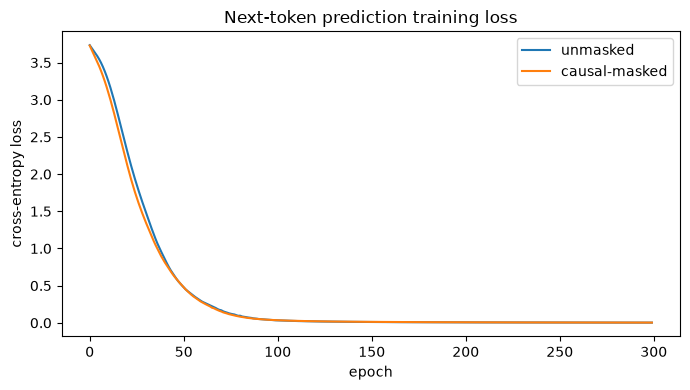

Final unmasked loss: 0.0027
Final masked loss:   0.0032


In [23]:
# Sanity check: both models should show a clearly decreasing loss curve, confirming the
# embeddings and Q/K/V projections are actually learning (not just visualizing random init).
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(unmasked_losses, label="unmasked")
ax.plot(masked_losses, label="causal-masked")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Next-token prediction training loss")
ax.legend()
plt.tight_layout()
plt.savefig("figures/training_loss.png", dpi=150)
plt.show()

print(f"Final unmasked loss: {unmasked_losses[-1]:.4f}")
print(f"Final masked loss:   {masked_losses[-1]:.4f}")

## 6. Part 1 Deliverable — Unmasked Self-Attention Heatmap

We run the full 42-token sequence through the trained **unmasked** model in eval mode and pull
out the attention weight matrix (`seq_len x seq_len`, rows sum to 1 after softmax). Because the
model was actually trained (not randomly initialized), this heatmap should show structured,
non-uniform attention patterns rather than noise.

In [24]:
unmasked_model.eval()
with torch.no_grad():
    _, unmasked_attn = unmasked_model(token_ids)

unmasked_attn_np = unmasked_attn.cpu().numpy()
print("Unmasked attention matrix shape:", unmasked_attn_np.shape)
print("Row sums (should all be ~1.0):", unmasked_attn_np.sum(axis=-1)[:5], "...")

Unmasked attention matrix shape: (51, 51)
Row sums (should all be ~1.0): [1.        0.9999999 1.        1.        1.       ] ...


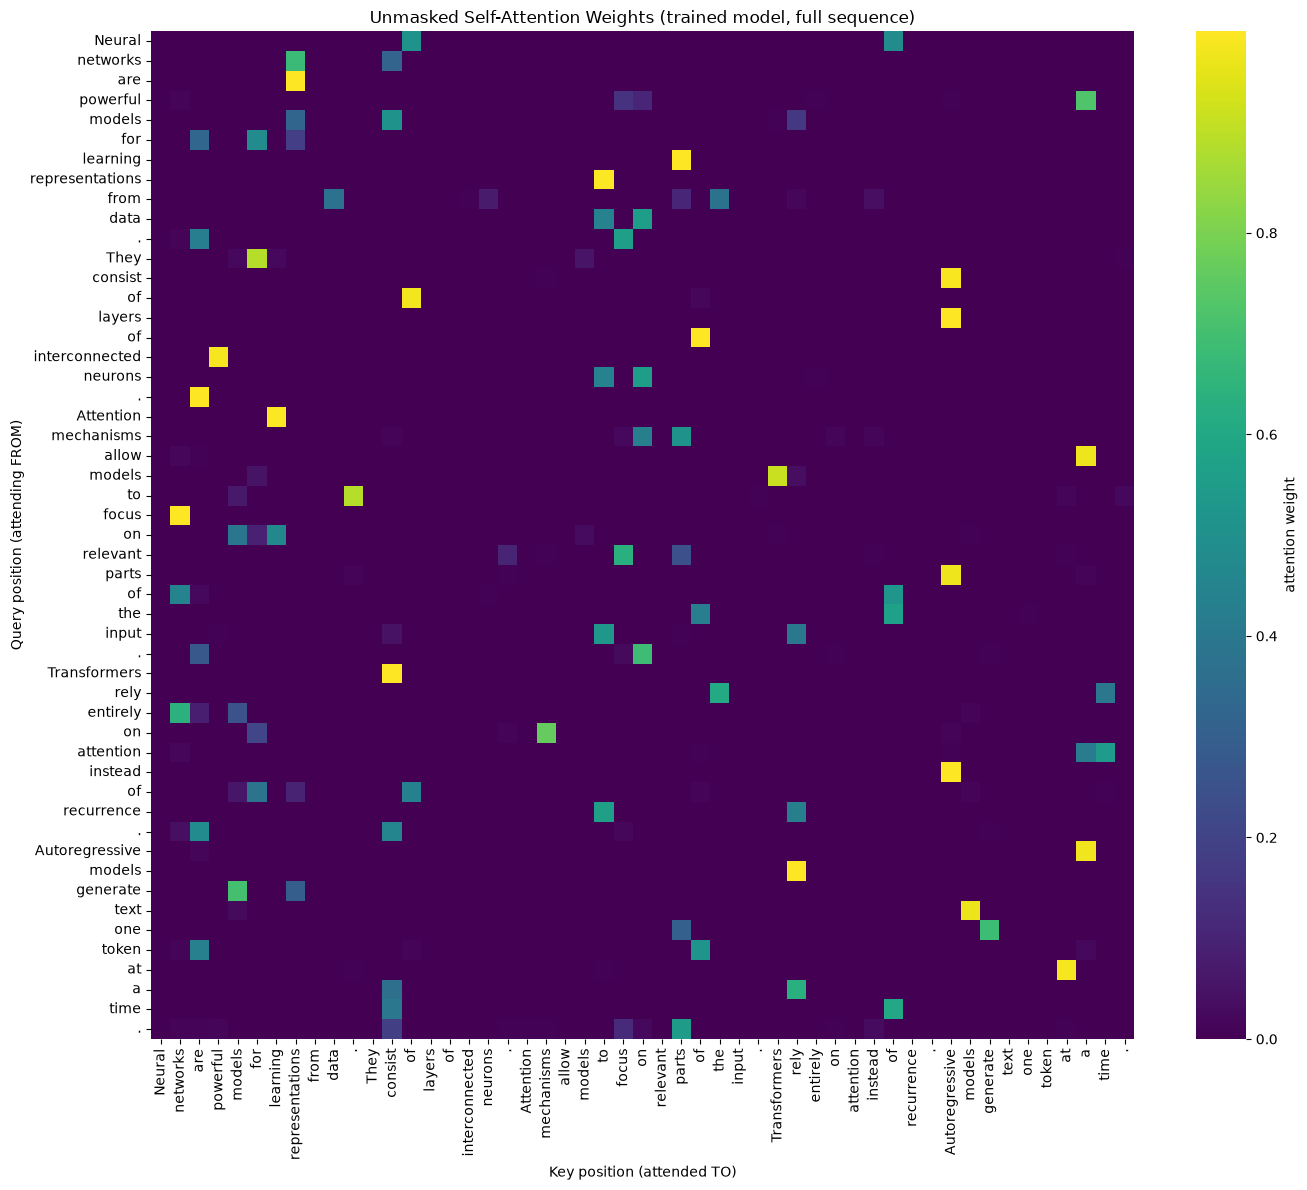

In [25]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    unmasked_attn_np,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis",
    ax=ax,
    cbar_kws={"label": "attention weight"},
)
ax.set_title("Unmasked Self-Attention Weights (trained model, full sequence)")
ax.set_xlabel("Key position (attended TO)")
ax.set_ylabel("Query position (attending FROM)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/unmasked_attention_heatmap.png", dpi=150)
plt.show()

## 7. Part 2 Deliverable — Causal Masking

We now apply a **lower-triangular causal mask** to the attention scores *before* the softmax:
position $i$ may only attend to positions $\le i$; every position $j > i$ gets an additive
$-\infty$ bias, so `softmax` drives its weight to exactly 0. This is exactly the decoder
self-attention masking described in Section 3.2.3 of *Attention Is All You Need*.

The mask is built in `AttentionLM.__init__` above (`torch.triu(..., diagonal=1)` filled with
`-inf`) and was already used **during training** of `masked_model`, so what we visualize below
is the causal attention pattern of a model that was actually trained under that constraint —
not just an unmasked model with a mask bolted on at inference time.

In [26]:
masked_model.eval()
with torch.no_grad():
    _, causal_attn = masked_model(token_ids)

causal_attn_np = causal_attn.cpu().numpy()

# Verify no probability mass leaks into future positions (strictly upper-triangular part == 0).
upper_triangle_mass = np.triu(causal_attn_np, k=1).sum()
print(f"Total attention mass on FUTURE positions (should be ~0): {upper_triangle_mass:.10f}")
print("Row sums (should all be ~1.0):", causal_attn_np.sum(axis=-1)[:5], "...")

Total attention mass on FUTURE positions (should be ~0): 0.0000000000
Row sums (should all be ~1.0): [1.         1.         1.         0.99999994 1.        ] ...


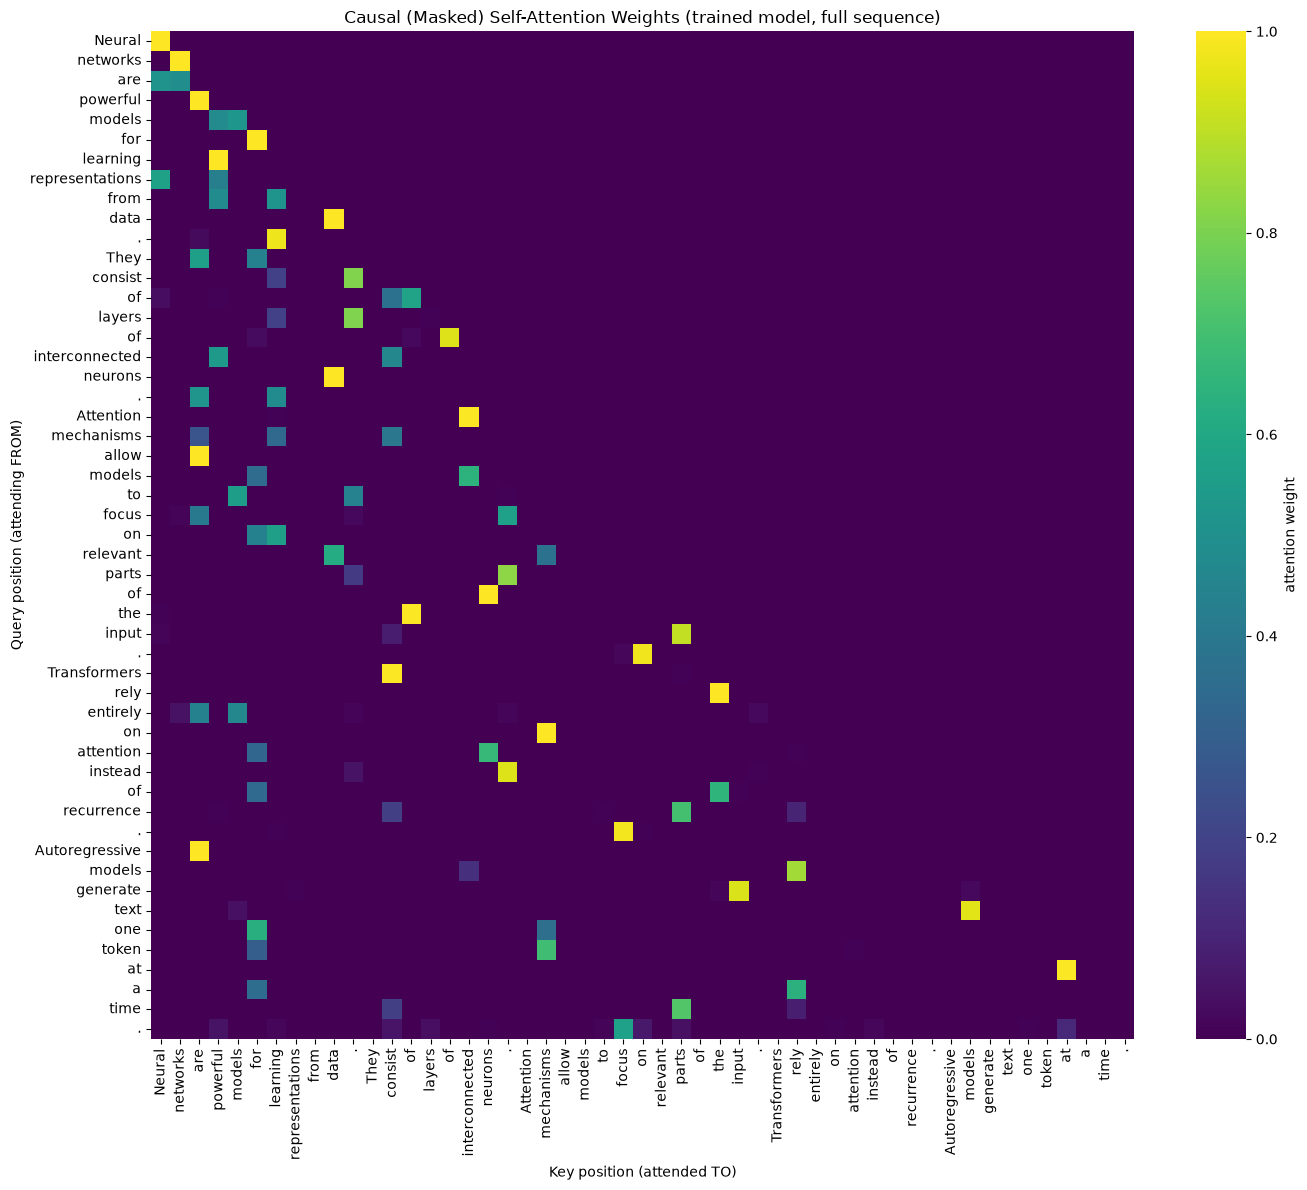

In [27]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    causal_attn_np,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis",
    ax=ax,
    cbar_kws={"label": "attention weight"},
)
ax.set_title("Causal (Masked) Self-Attention Weights (trained model, full sequence)")
ax.set_xlabel("Key position (attended TO)")
ax.set_ylabel("Query position (attending FROM)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/causal_attention_heatmap.png", dpi=150)
plt.show()

## 8. Observations

- **Training actually happened**: both loss curves drop sharply from `ln(VOCAB_SIZE)` (random-
  guess loss) toward a much lower value within a few hundred epochs, confirming the embeddings
  and $W_Q, W_K, W_V$ projections are genuinely learned rather than left at random init — the
  heatmaps above reflect that learned structure, not noise.
- **Unmasked heatmap**: attention is spread across the full row for every query position,
  including columns to the *right* of the diagonal — every token can freely attend to tokens that
  come after it in the sequence, which is expected for bidirectional self-attention with no mask.
- **Causal heatmap**: the entire strict upper triangle is exactly 0 (`upper_triangle_mass` printed
  above is ~0 to floating-point precision) — visually, the heatmap is solid dark above the
  diagonal and only has non-zero weight on/below it. Row 0 (the first token) can only attend to
  itself, so its row is a single spike of weight 1.0 at column 0; each subsequent row has one more
  available column than the last, producing the characteristic triangular pattern of decoder
  self-attention.
- This directly demonstrates the mechanism Section 3.2.3 of *Attention Is All You Need* describes
  for autoregressive decoding: causal masking prevents a position from using information about
  future tokens it would not have access to at generation time.